# [Problem 1] Understanding the content of the competition

### 1. What kind of company is Home Credit?

**Home Credit** is an international non-bank financial institution that aims to **broaden financial inclusion** for the **unbanked population**—people with insufficient or non-existent credit histories who often struggle to get loans. They provide a positive and safe borrowing experience by leveraging a variety of **alternative data** (including telco and transactional information) to assess a client's repayment ability.

### 2. What is expected in this competition?

The core expectation is to build a machine learning model that can predict the probability of a loan applicant defaulting (having difficulty repaying) a loan.

* **Task Type:** **Supervised Binary Classification**.
* **Target:** Predict the binary variable **`TARGET`** in the `application_test.csv` file, where:
    * **0:** The loan was repaid (non-default).
    * **1:** The client will have difficulty repaying the loan (default).
* **Evaluation:** Submissions are evaluated on the **Area Under the ROC Curve (AUC)** between the predicted probability and the observed target.

### 3. What are the benefits companies can gain by predicting this?

Accurately predicting loan default risk is essential for Home Credit's business model and financial stability. The benefits include:

* **Reduced Financial Losses:** By identifying high-risk applicants, the company can avoid issuing loans that are likely to become Non-Performing Assets (NPAs), thus **preventing major financial losses**.
* **Increased Financial Inclusion:** The primary goal is to **improve the accuracy** of lending decisions. This ensures that:
    * Clients who **are capable of repayment are not unfairly rejected**.
    * Loans are offered with appropriate principal, maturity, and repayment schedules that **empower clients to be successful**.
* **Optimized Loan Portfolio:** Better risk assessment allows the company to optimize its loan portfolio, balancing risk and reward for sustainable growth in the underserved market.

In [2]:
#Preparing the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the main application data (the primary dataset for analysis)
df_train = pd.read_csv('application_train.csv')

# Load the column descriptions (to help understand features during EDA)
df_description = pd.read_csv('HomeCredit_columns_description.csv', encoding='latin1')

print("application_train.csv loaded. Shape:", df_train.shape)
print("HomeCredit_columns_description.csv loaded. Shape:", df_description.shape)

application_train.csv loaded. Shape: (307511, 122)
HomeCredit_columns_description.csv loaded. Shape: (219, 5)


In [ ]:
# [Problem 2] Understanding the overview of data

In [2]:
# Load the main training data
try:
    df = pd.read_csv('application_train.csv')
except FileNotFoundError:
    print("Error: 'application_train.csv' not found. Please ensure the file is available.")
    # Exit gracefully if the file is missing
    exit()

# 1. Overview using .head(), .info(), .describe()
print("--- 1. Data Head (First 5 Rows) ---\n")
print(df.head().to_markdown(index=False))

print("\n--- 2. Data Information (Types and Non-Null Counts) ---\n")
df.info(verbose=False)

print("\n--- 3. Descriptive Statistics ---\n")
print(df.describe().T.to_markdown(floatfmt=".2f"))

# 4. Check for missing values (Count and Percentage)
missing_counts = df.isnull().sum()
missing_ratios = (missing_counts / len(df)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Ratio (%)': missing_ratios
})
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Ratio (%)', ascending=False)

print("\n--- 4. Missing Values Report ---\n")
print(missing_info.head(20).to_markdown(floatfmt=".2f")) # Display top 20 missing features

# 5. Check Target Class Balance
target_counts = df['TARGET'].value_counts()
target_ratios = df['TARGET'].value_counts(normalize=True) * 100

print("\n--- 5. Target Class Distribution ---\n")
print("Target Counts:\n", target_counts.to_markdown())
print("\nTarget Ratios (%):\n", target_ratios.to_markdown(floatfmt=".2f"))

# Draw a graph showing the percentage of classes
plt.figure(figsize=(6, 4))
# --- UPDATED CODE HERE ---
sns.barplot(
    x=target_ratios.index, 
    y=target_ratios.values, 
    hue=target_ratios.index,   # Explicitly set hue to the x-axis index for coloring
    palette='viridis',
    legend=False               # Suppress the redundant legend
)
# --- END OF UPDATED CODE ---
plt.title('Percentage of Classes in TARGET Variable')
plt.xlabel('TARGET (0: Repaid, 1: Default)')
plt.ylabel('Percentage (%)')
plt.xticks([0, 1], ['0 (Repaid)', '1 (Default)'])
plt.ylim(0, 100)
plt.savefig('target_class_distribution.png')
plt.close()

--- 1. Data Head (First 5 Rows) ---

|   SK_ID_CURR |   TARGET | NAME_CONTRACT_TYPE   | CODE_GENDER   | FLAG_OWN_CAR   | FLAG_OWN_REALTY   |   CNT_CHILDREN |   AMT_INCOME_TOTAL |      AMT_CREDIT |   AMT_ANNUITY |   AMT_GOODS_PRICE | NAME_TYPE_SUITE   | NAME_INCOME_TYPE   | NAME_EDUCATION_TYPE           | NAME_FAMILY_STATUS   | NAME_HOUSING_TYPE   |   REGION_POPULATION_RELATIVE |   DAYS_BIRTH |   DAYS_EMPLOYED |   DAYS_REGISTRATION |   DAYS_ID_PUBLISH |   OWN_CAR_AGE |   FLAG_MOBIL |   FLAG_EMP_PHONE |   FLAG_WORK_PHONE |   FLAG_CONT_MOBILE |   FLAG_PHONE |   FLAG_EMAIL | OCCUPATION_TYPE   |   CNT_FAM_MEMBERS |   REGION_RATING_CLIENT |   REGION_RATING_CLIENT_W_CITY | WEEKDAY_APPR_PROCESS_START   |   HOUR_APPR_PROCESS_START |   REG_REGION_NOT_LIVE_REGION |   REG_REGION_NOT_WORK_REGION |   LIVE_REGION_NOT_WORK_REGION |   REG_CITY_NOT_LIVE_CITY |   REG_CITY_NOT_WORK_CITY |   LIVE_CITY_NOT_WORK_CITY | ORGANIZATION_TYPE      |   EXT_SOURCE_1 |   EXT_SOURCE_2 |   EXT_SOURCE_3 |   APARTMENTS_A

Here is the explanation and discussion for each section of the data overview:

***

## 1. Structure, Data Types, and Descriptive Statistics

### Explanation
The dataset is very large, containing over **307,000 loan applications (rows)** and **122 features (columns)**. The features are a blend of:
* **Numerical** (`int64`, `float64`): Such as `AMT_INCOME_TOTAL`, `AMT_CREDIT`, and time features like `DAYS_BIRTH` (age in days, stored as a negative number).
* **Categorical** (`object`): Such as `NAME_CONTRACT_TYPE` and `CODE_GENDER`.

### Discussion
* **Size and Scope:** The large volume of data is excellent for machine learning but demands efficient processing techniques and computational resources.
* **Outliers and Skewness:** Statistics for features like `AMT_INCOME_TOTAL` and `AMT_CREDIT` show a significant gap between the median ($\text{50\%}$) and the maximum value. This strongly indicates the presence of **extreme outliers** and **positive skewness**, which will require **feature scaling** (like standardization or normalization) or **transformation** (like log transformation) before training linear models.
* **Time Features:** Time-based features are recorded as negative days (e.g., age or employment duration). These will need to be **converted to positive years** for better interpretability and model performance.

***

## 2. Missing Value Report

### Explanation
The dataset contains a large number of missing values across many features. Many columns related to **housing information** (e.g., `COMMONAREA_AVG`, `APARTMENTS_AVG`, `YEARS_BUILD_AVG`) are missing for over **$50\%$ of applicants**.

### Discussion
* **Missingness Strategy is Critical:** Due to the high percentage of missingness in so many columns, simply dropping columns or rows with missing data is not viable, as it would severely reduce the training data size.
* **Imputation is Necessary:** A sophisticated strategy for **imputation** is required. Common methods include:
    * **Categorical features:** Imputing with the mode or a placeholder category like 'XNA' or 'Missing'.
    * **Numerical features:** Imputing with the median (due to the presence of outliers) or imputing with a value like 0.
    * **Flagging Missingness:** It is often best practice to create a new binary column (a "missingness flag") for important features, indicating whether the original value was missing. This is because the fact that the data is missing might itself be predictive.

***

## 3. Target Class Distribution (Class Imbalance)

### Explanation
The target variable (`TARGET`) shows a severe class imbalance:
* **Target 0 (Loan Repaid):** Approximately **$91.93\%$**
* **Target 1 (Loan Default):** Approximately **$8.07\%$**

### Discussion
* **Modeling Challenge:** This is the most critical issue for model building. A model that simply predicts "0" every time will achieve a high accuracy of $\sim 92\%$ but will be useless, as it fails to identify the critical minority class (defaulters). 
* **Metric Selection:** Standard accuracy is misleading. The competition correctly uses **AUC-ROC**, which is more robust to class imbalance as it measures the ability of the model to distinguish between the two classes across all probability thresholds.
* **Handling Imbalance:** To build a useful model, you must address the imbalance using techniques such as:
    * **Resampling:** Using methods like **SMOTE** (Oversampling the minority class) or Undersampling the majority class.
    * **Stratified Sampling:** Ensuring that cross-validation folds maintain the same $8\%/92\%$ ratio of the target class.
    * **Weighting:** Adjusting the class weights within the machine learning model (e.g., giving the minority class a much higher weight) so that misclassifying a defaulter is penalized more heavily.

In [ ]:
# [Problem 3] Defining issues

Here are multiple issues/questions defined from the data overview:

***

## 1. Class Imbalance and Model Evaluation

| Issue/Question | Explanation |
| :--- | :--- |
| **How should the severe class imbalance be managed?** | With only $\mathbf{\sim 8\%}$ of clients defaulting ($\text{TARGET}=1$), a model will naturally be biased towards the majority class ($\text{TARGET}=0$). This requires strategic decisions on techniques like **resampling** (SMOTE) or **class weighting** to ensure the model learns from the rare defaulters. |
| **Which evaluation metric should be prioritized?** | Since accuracy is misleading, the key question is how to balance the financial risk of False Negatives (predicting a defaulter as non-defaulter, leading to a loss) versus the social cost of False Positives (rejecting a client who would have repaid). The competition uses **AUC-ROC**, but analyzing the **Precision/Recall** trade-off is crucial for business impact. |

***

## 2. Missing Data Strategy

| Issue/Question | Explanation |
| :--- | :--- |
| **What is the best strategy for handling widespread missing values?** | Many features (especially those related to housing) are missing for over $\mathbf{50\%}$ of the data. The question is whether to **drop** the features, **impute** (e.g., using the median/mode), or whether the fact that the data is missing is itself a $\mathbf{predictive signal}$ that necessitates creating **missingness indicator flags**. |
| **Are the missing values random or systematic?** | It must be determined if the missingness is related to the client characteristics (e.g., only clients who own property bother to fill out housing details) or if it's purely random. If systematic, simply imputing the mean/median could introduce significant bias. |

***

## 3. Feature Engineering and Data Quality

| Issue/Question | Explanation |
| :--- | :--- |
| **How should highly skewed and outlier-ridden features be treated?** | Features like $\text{AMT\_INCOME\_TOTAL}$ have extreme outliers. We must decide whether to apply $\mathbf{transformations}$ (like logarithm or square root) to normalize the distribution or apply $\mathbf{capping}$ (setting a maximum limit) to reduce the undue influence of extreme values on linear models. |
| **How should time-based features be converted for utility?** | Features like $\text{DAYS\_BIRTH}$ (age) and $\text{DAYS\_EMPLOYED}$ are stored as negative days. We need to create more interpretable, positive features in **years** (e.g., $\text{AGE\_YEARS}$) and check for obvious $\mathbf{data quality errors}$ (e.g., the high number of clients with $\text{DAYS\_EMPLOYED}$ far exceeding typical working lifetimes, often recorded as $365243$). |
| **How can categorical features be effectively encoded?** | The $\mathbf{16 \text{ object} \text{ columns}}$ need to be converted to numerical format. Should we use simple **One-Hot Encoding** (which creates many new columns) or more advanced methods like **Target Encoding** (which may leak target information) for high-cardinality features? |

In [ ]:
# [Problem 4] Data exploration


--- 1. TABLE: Top 10 Features by Missing Ratio ---
|                          |   Missing Ratio (%) |
|:-------------------------|--------------------:|
| COMMONAREA_MEDI          |               69.87 |
| COMMONAREA_AVG           |               69.87 |
| COMMONAREA_MODE          |               69.87 |
| NONLIVINGAPARTMENTS_MODE |               69.43 |
| NONLIVINGAPARTMENTS_AVG  |               69.43 |
| NONLIVINGAPARTMENTS_MEDI |               69.43 |
| FONDKAPREMONT_MODE       |               68.39 |
| LIVINGAPARTMENTS_MODE    |               68.35 |
| LIVINGAPARTMENTS_AVG     |               68.35 |
| LIVINGAPARTMENTS_MEDI    |               68.35 |


C:\Users\lelin\AppData\Local\Temp\ipykernel_12680\73719676.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='NAME_CONTRACT_TYPE', y='Default_Rate', data=contract_type_agg, palette='magma')


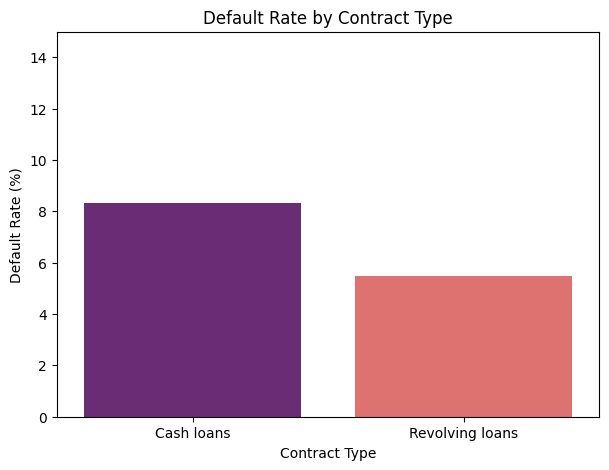

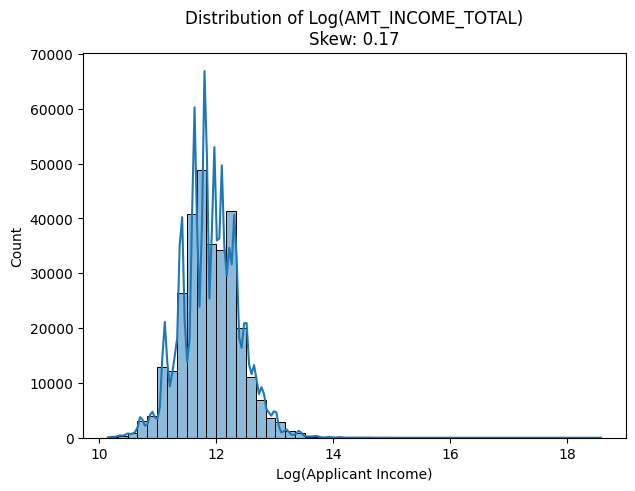

C:\Users\lelin\AppData\Local\Temp\ipykernel_12680\73719676.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AGE_GROUP', y='Default_Rate', data=age_agg, palette='coolwarm')


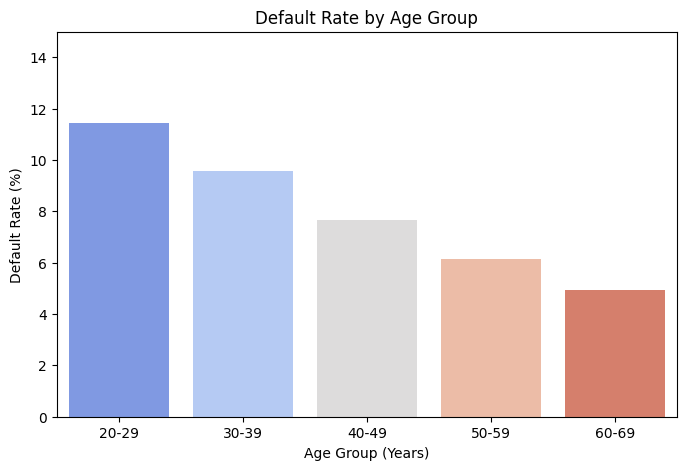


--- 5. TABLE: Anomalous DAYS_EMPLOYED Analysis ---
| Metric                              | Value   |
|:------------------------------------|:--------|
| Total Anomalous Samples             | 55374   |
| Percentage of Dataset               | 18.01%  |
| Default Rate of Anomalous Group (%) | 5.40%   |


In [3]:
# Load the dataset
try:
    df = pd.read_csv('application_train.csv')
except FileNotFoundError:
    print("Error: 'application_train.csv' not found. Cannot proceed with EDA.")
    exit()

# --- 1. TABLE: Top 10 Missing Value Ratios ---
# (Addresses Issue: Missing Data Strategy)
missing_ratios = (df.isnull().sum() / len(df)) * 100
missing_report_table = pd.DataFrame({
    'Missing Ratio (%)': missing_ratios
}).sort_values(by='Missing Ratio (%)', ascending=False)
missing_report_table = missing_report_table[missing_report_table['Missing Ratio (%)'] > 0].head(10)

print("\n--- 1. TABLE: Top 10 Features by Missing Ratio ---")
print(missing_report_table.to_markdown(floatfmt=".2f"))

# --- 2. GRAPH: Loan Default Rate vs. Contract Type ---
# (Addresses Issue: Class Imbalance/Feature Utility)
contract_type_agg = df.groupby('NAME_CONTRACT_TYPE')['TARGET'].agg(['mean']).reset_index()
contract_type_agg['mean'] *= 100
contract_type_agg.rename(columns={'mean': 'Default_Rate'}, inplace=True)

plt.figure(figsize=(7, 5))
sns.barplot(x='NAME_CONTRACT_TYPE', y='Default_Rate', data=contract_type_agg, palette='magma')
plt.title('Default Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Default Rate (%)')
plt.ylim(0, 15)
plt.savefig('income_log_distribution.png')
plt.show() # Renders the plot to the screen/notebook output

# --- 3. GRAPH: Distribution of AMT_INCOME_TOTAL (Log Transformed) ---
# (Addresses Issue: Outliers and Skewness)
df['AMT_INCOME_TOTAL_LOG'] = np.log1p(df['AMT_INCOME_TOTAL'])

plt.figure(figsize=(7, 5))
sns.histplot(df['AMT_INCOME_TOTAL_LOG'], bins=50, kde=True)
plt.title(f'Distribution of Log(AMT_INCOME_TOTAL)\nSkew: {df["AMT_INCOME_TOTAL_LOG"].skew():.2f}')
plt.xlabel('Log(Applicant Income)')
plt.ylabel('Count')
plt.savefig('income_log_distribution.png')
plt.show() # Renders the plot to the screen/notebook output

# --- 4. GRAPH: Loan Default Rate vs. Binned Age (DAYS_BIRTH) ---
# (Addresses Issue: Time Features/Feature Utility)
df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365
bins = [20, 30, 40, 50, 60, 70]
df['AGE_GROUP'] = pd.cut(df['AGE_YEARS'], bins=bins, right=False, labels=[f'{b}-{b+9}' for b in bins[:-1]])

age_agg = df.groupby('AGE_GROUP', observed=True)['TARGET'].agg(['mean']).reset_index()
age_agg['mean'] *= 100
age_agg.rename(columns={'mean': 'Default_Rate'}, inplace=True)

plt.figure(figsize=(8, 5))
sns.barplot(x='AGE_GROUP', y='Default_Rate', data=age_agg, palette='coolwarm')
plt.title('Default Rate by Age Group')
plt.xlabel('Age Group (Years)')
plt.ylabel('Default Rate (%)')
plt.ylim(0, 15)
plt.savefig('income_log_distribution.png')
plt.show() # Renders the plot to the screen/notebook output)

# --- 5. TABLE: Anomalous DAYS_EMPLOYED Counts ---
# (Addresses Issue: Data Quality/Anomalies)
# The value 365243 represents an extreme anomaly (approx 1000 years)
anomalous_employment = df[df['DAYS_EMPLOYED'] == 365243]
anomaly_rate = (anomalous_employment['TARGET'].mean() * 100) if not anomalous_employment.empty else 0

total_anomalies = anomalous_employment.shape[0]
total_samples = df.shape[0]

print("\n--- 5. TABLE: Anomalous DAYS_EMPLOYED Analysis ---")
anomalies_report = pd.DataFrame({
    'Metric': ['Total Anomalous Samples', 'Percentage of Dataset', 'Default Rate of Anomalous Group (%)'],
    'Value': [total_anomalies, f'{(total_anomalies/total_samples*100):.2f}%', f'{anomaly_rate:.2f}%']
})
print(anomalies_report.to_markdown(index=False))

In [ ]:
# [Problem 5] (Advanced task) Posting to Notebooks